# NeuroScope AI - Notebook 07: Breast Cancer Detection

Trains EfficientNet-B4 on CBIS-DDSM for mammography classification.

Tasks:
1. Binary classification -- benign vs malignant
2. BI-RADS scoring -- automated 1-5 scoring
3. Lesion type -- mass vs calcification

Datasets:
- CBIS-DDSM (primary training, 10,243 images)
- INbreast (Portuguese validation)
- CMMD (Chinese diversity)
- KAU-BCMD (Saudi diversity)

Key preprocessing:
- CLAHE (Contrast Limited Adaptive Histogram Equalization)
- Essential for low-contrast mammography images

Estimated runtime on RTX 4060:
- ~5-8 min per epoch
- 30 epochs total ~ 3-4 hours

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, yaml, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from efficientnet_pytorch import EfficientNet

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
CKPT = os.path.join(BASE, 'checkpoints', 'breast_det')
OUT  = os.path.join(BASE, 'outputs', 'nb07_breast_det')
os.makedirs(CKPT, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)
sys.path.insert(0, BASE)

with open(os.path.join(BASE, 'configs', 'master_config.yaml'), encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print('Imports OK')

Device : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB
Imports OK


---
## Cell 2 - Training Config

In [2]:
BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS        = os.path.join(BASE, 'datasets')

CBIS_PATH     = os.path.join(DS, 'breast', 'cbis_ddsm')
INBREAST_PATH = os.path.join(DS, 'breast', 'inbreast')
CMMD_PATH     = os.path.join(DS, 'breast', 'cmmd')
KAU_PATH      = os.path.join(DS, 'breast', 'kau_bcmd')

# Model
BACKBONE     = 'efficientnet-b4'
IMG_SIZE     = 512     # mammography needs higher resolution
DROPOUT      = 0.3

# Training
BATCH_SIZE   = 16
MAX_EPOCHS   = 30
LR           = 1e-4
WEIGHT_DECAY = 1e-4
VAL_FRAC     = 0.15
NUM_WORKERS  = 0
AMP          = True

# Labels
PATHOLOGY_MAP = {
    'BENIGN': 0,
    'BENIGN_WITHOUT_CALLBACK': 0,
    'MALIGNANT': 1,
}

print('Config:')
print(f'  Backbone  : {BACKBONE}')
print(f'  Image size: {IMG_SIZE}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Max epochs: {MAX_EPOCHS}')

Config:
  Backbone  : efficientnet-b4
  Image size: 512
  Batch size: 16
  Max epochs: 30


---
## Cell 3 - Inspect CBIS-DDSM Structure

In [3]:
import os, pandas as pd

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CBIS_PATH = os.path.join(BASE, 'datasets', 'breast', 'cbis_ddsm')

# Find all CSV files
csv_files = []
for root, dirs, files in os.walk(CBIS_PATH):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

print('CSV files found:')
for c in csv_files:
    df = pd.read_csv(c)
    print(f'  {os.path.basename(c)}')
    print(f'    Rows: {len(df):,}  Cols: {list(df.columns)}')
    print()

# Count JPEG images
jpeg_count = sum(1 for r, d, f in os.walk(CBIS_PATH)
                 for fi in f if fi.lower().endswith('.jpg'))
print(f'Total JPEG images: {jpeg_count:,}')

# Show folder structure
print('\nFolder structure:')
for item in sorted(os.listdir(CBIS_PATH)):
    fp = os.path.join(CBIS_PATH, item)
    if os.path.isdir(fp):
        n = sum(len(f) for _, _, f in os.walk(fp))
        print(f'  {item}/  [{n:,} files]')
    else:
        print(f'  {item}')

CSV files found:
  calc_case_description_test_set.csv
    Rows: 326  Cols: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']

  calc_case_description_train_set.csv
    Rows: 1,546  Cols: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']

  dicom_info.csv
    Rows: 10,237  Cols: ['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex',

---
## Cell 4 - CBIS-DDSM Dataset

In [5]:
import os, cv2, torch, numpy as np, pandas as pd
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

BASE         = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CBIS_PATH    = os.path.join(BASE, 'datasets', 'breast', 'cbis_ddsm')
IMG_SIZE     = 512
BATCH_SIZE   = 16
NUM_WORKERS  = 0

PATHOLOGY_MAP = {
    'BENIGN': 0, 'BENIGN_WITHOUT_CALLBACK': 0, 'MALIGNANT': 1
}


def apply_clahe(img_gray):
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    return clahe.apply(img_gray)


def get_transforms(mode='train', img_size=512):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.Rotate(limit=10, p=0.4),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def find_cbis_samples(cbis_root):
    # ── 1. Single walk: index every JPEG by its parent folder name (SeriesUID) ──
    uid_to_jpeg = {}
    dicom_info_path = None

    for root, dirs, files in os.walk(cbis_root):
        uid = os.path.basename(root)
        jpegs = [f for f in files if f.lower().endswith('.jpg')]
        if jpegs:
            best = max(jpegs, key=lambda f: os.path.getsize(os.path.join(root, f)))
            uid_to_jpeg[uid] = os.path.join(root, best)
        for f in files:
            if f == 'dicom_info.csv':
                dicom_info_path = os.path.join(root, f)

    print(f'Disk walk done: {len(uid_to_jpeg):,} UID folders with JPEGs')

    # ── 2. Load all 4 case CSVs ──────────────────────────────────────────────
    csv_names = {
        'calc_case_description_train_set.csv',
        'calc_case_description_test_set.csv',
        'mass_case_description_train_set.csv',
        'mass_case_description_test_set.csv',
    }
    all_rows = []
    for root, dirs, files in os.walk(cbis_root):
        for f in files:
            if f in csv_names:
                df = pd.read_csv(os.path.join(root, f))
                all_rows.append(df)
                print(f'  Loaded {f}: {len(df):,} rows')

    if not all_rows:
        raise RuntimeError('No case CSVs found under CBIS_PATH')

    combined  = pd.concat(all_rows, ignore_index=True)
    path_col  = next((c for c in combined.columns if 'image file path' in c.lower()), None)
    label_col = next((c for c in combined.columns if 'pathology'       in c.lower()), None)
    print(f'  path_col={path_col!r}  label_col={label_col!r}')

    if not path_col or not label_col:
        raise RuntimeError(f'Expected columns not found. Got: {list(combined.columns)}')

    # ── 3. Join ──────────────────────────────────────────────────────────────
    # CSV path: "Calc-Test_P_00038_LEFT_CC/<UID1>/<UID2>/000000.dcm"
    #   parts[0] = patient folder  (NOT a UID)
    #   parts[1] = UID1            <- full-mammogram series
    #   parts[2] = UID2            <- ROI/crop series
    # Try UID1 first (full mammogram), fall back to UID2 (crop).
    samples = []
    miss    = 0
    for _, row in combined.iterrows():
        lbl_str = str(row[label_col]).upper().strip()
        lbl     = PATHOLOGY_MAP.get(lbl_str, -1)
        if lbl == -1:
            continue

        parts = str(row[path_col]).replace('\\', '/').split('/')
        uid1  = parts[1] if len(parts) > 1 else None
        uid2  = parts[2] if len(parts) > 2 else None

        img_path = uid_to_jpeg.get(uid1) or uid_to_jpeg.get(uid2)

        if img_path:
            samples.append((img_path, lbl))
        else:
            miss += 1

    counts = Counter(s[1] for s in samples)
    print(f'\nSamples matched : {len(samples):,}  (missed: {miss:,})')
    print(f'  Benign        : {counts.get(0, 0):,}')
    print(f'  Malignant     : {counts.get(1, 0):,}')
    return samples


class BreastDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        img     = apply_clahe(img)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        if self.transform:
            img_rgb = self.transform(image=img_rgb)['image']
        return img_rgb, label


# ── Build samples ────────────────────────────────────────────────────────────
all_samples = find_cbis_samples(CBIS_PATH)

if len(all_samples) < 10:
    raise RuntimeError(
        f'Only {len(all_samples)} samples found — see DIAGNOSTIC output above.'
    )

tr_samples, va_samples = train_test_split(
    all_samples, test_size=0.15, random_state=42,
    stratify=[s[1] for s in all_samples]
)

tr_ds = BreastDataset(tr_samples, get_transforms('train', IMG_SIZE))
va_ds = BreastDataset(va_samples, get_transforms('val',   IMG_SIZE))

tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

imgs, labels = next(iter(tr_dl))
print(f'\nBatch  : imgs={imgs.shape}, labels={labels.shape}')
print(f'Train  : {len(tr_ds):,}  Val: {len(va_ds):,}')
print(f'Batches: {len(tr_dl)}')
print('Dataset OK')

Disk walk done: 6,774 UID folders with JPEGs
  Loaded calc_case_description_test_set.csv: 326 rows
  Loaded calc_case_description_train_set.csv: 1,546 rows
  Loaded mass_case_description_test_set.csv: 378 rows
  Loaded mass_case_description_train_set.csv: 1,318 rows
  path_col='image file path'  label_col='pathology'

Samples matched : 3,568  (missed: 0)
  Benign        : 2,111
  Malignant     : 1,457

Batch  : imgs=torch.Size([16, 3, 512, 512]), labels=torch.Size([16])
Train  : 3,032  Val: 536
Batches: 189
Dataset OK


---
## Cell 5 - EfficientNet-B4 Model

In [6]:
import torch
import torch.nn as nn
from efficientnet_pytorch import EfficientNet

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DROPOUT = 0.3


class BreastClassifier(nn.Module):
    """
    EfficientNet-B4 for breast cancer classification.
    Single binary output: 0=benign, 1=malignant.
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        self.backbone  = EfficientNet.from_pretrained('efficientnet-b4')
        in_features    = self.backbone._fc.in_features
        self.backbone._fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, 1),  # binary output
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)   # [B, 1] raw logits


model = BreastClassifier(DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model      : BreastClassifier (EfficientNet-B4)')
print(f'Parameters : {n_params:,}')

with torch.no_grad():
    dummy = torch.zeros(2, 3, 512, 512).to(DEVICE)
    out   = model(dummy)
    print(f'Forward    : {dummy.shape} -> {out.shape}')
    del dummy, out
    torch.cuda.empty_cache()
print('Model OK')

Loaded pretrained weights for efficientnet-b4
Model      : BreastClassifier (EfficientNet-B4)
Parameters : 18,533,449
Forward    : torch.Size([2, 3, 512, 512]) -> torch.Size([2, 1])
Model OK


---
## Cell 6 - Loss, Optimizer, Scheduler

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from collections import Counter

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR           = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 30
AMP          = True

if 'tr_samples' not in dir():
    raise RuntimeError('tr_samples not defined — run Cell 4 first.')

# Compute class weights for imbalanced dataset
label_counts = Counter(s[1] for s in tr_samples)
n_total      = len(tr_samples)
pos_weight   = torch.tensor(
    [label_counts[0] / max(label_counts[1], 1)],
    dtype=torch.float32
).to(DEVICE)

print(f'Class balance: benign={label_counts[0]:,}, malignant={label_counts[1]:,}')
print(f'Pos weight   : {pos_weight.item():.2f}')

loss_fn   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': LR * 0.1},
    {'params': model.head.parameters()},
], lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=1, eta_min=1e-6
)
scaler = GradScaler(enabled=AMP)

print('Loss      : BCEWithLogitsLoss (weighted)')
print('Optimizer : AdamW (backbone LR=1e-5, head LR=1e-4)')
print('OK')

Class balance: benign=1,794, malignant=1,238
Pos weight   : 1.45
Loss      : BCEWithLogitsLoss (weighted)
Optimizer : AdamW (backbone LR=1e-5, head LR=1e-4)
OK


---
## Cell 7 - Checkpoint Utilities

In [8]:
import os, torch, json

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'breast_det')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_auc, history, tag='last'):
    path = os.path.join(CKPT, f'breast_det_{tag}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'metrics': metrics,
        'best_auc': best_auc,
        'history': history,
    }, path)
    json_path = os.path.join(CKPT, f'breast_det_{tag}_summary.json')
    with open(json_path, 'w') as f:
        json.dump({'epoch': epoch, **metrics, 'best_auc': best_auc}, f, indent=2)


def load_checkpoint(model, optimizer, scheduler, scaler, tag='last'):
    path = os.path.join(CKPT, f'breast_det_{tag}.pth')
    if not os.path.exists(path):
        print(f'No checkpoint at {path} - starting from scratch')
        return 0, 0.0, []
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    epoch    = ckpt['epoch']
    best_auc = ckpt.get('best_auc', 0.0)
    history  = ckpt.get('history', [])
    print(f'Resumed from epoch {epoch}, best_auc={best_auc:.4f}')
    return epoch + 1, best_auc, history


for tag in ['last', 'best']:
    p = os.path.join(CKPT, f'breast_det_{tag}.pth')
    print(f'  {tag}.pth : {"EXISTS" if os.path.exists(p) else "not found"}')
print('Checkpoint utilities OK')

  last.pth : not found
  best.pth : not found
Checkpoint utilities OK


---
## Cell 8 - Training Loop

In [9]:
import os, time, torch, numpy as np
from torch.cuda.amp import autocast
from sklearn.metrics import roc_auc_score

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS = 30
AMP        = True
BASE       = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT       = os.path.join(BASE, 'checkpoints', 'breast_det')

start_epoch, best_auc, history = load_checkpoint(model, optimizer, scheduler, scaler)

print(f'Starting from epoch : {start_epoch}')
print(f'Max epochs          : {MAX_EPOCHS}')
print('-' * 65)


for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    # TRAIN
    model.train()
    train_loss = 0.0
    n_steps    = 0

    for step, (imgs, labels) in enumerate(tr_dl):
        imgs   = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)  # [B, 1]

        optimizer.zero_grad()

        with autocast(enabled=AMP):
            logits = model(imgs)
            loss   = loss_fn(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        n_steps    += 1

        if (step + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d} | Step {step+1:4d}/{len(tr_dl)} '
                  f'| Loss {train_loss/n_steps:.4f}')

    scheduler.step()
    avg_loss = train_loss / n_steps

    # VALIDATE
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in va_dl:
            imgs   = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.0

    preds_bin = (all_probs >= 0.5).astype(int)
    acc       = (preds_bin == all_labels).mean()
    tp = ((preds_bin == 1) & (all_labels == 1)).sum()
    fn = ((preds_bin == 0) & (all_labels == 1)).sum()
    sensitivity = tp / max(tp + fn, 1)

    elapsed = time.time() - t0
    metrics = {
        'train_loss':  avg_loss,
        'val_auc':     float(auc),
        'val_acc':     float(acc),
        'sensitivity': float(sensitivity),
    }

    print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} '
          f'| Loss {avg_loss:.4f} '
          f'| AUC {auc:.4f} '
          f'| Acc {acc:.4f} '
          f'| Sens {sensitivity:.4f} '
          f'| {elapsed/60:.1f}min')

    history.append({'epoch': epoch+1, **metrics})

    if auc > best_auc:
        best_auc = auc
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        metrics, best_auc, history, tag='best')
        print(f'  --> New best AUC={best_auc:.4f}')

    save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_auc, history, tag='last')


print()
print('=' * 65)
print(f'Training complete! Best AUC: {best_auc:.4f}')
print('=' * 65)

No checkpoint at C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\checkpoints\breast_det\breast_det_last.pth - starting from scratch
Starting from epoch : 0
Max epochs          : 30
-----------------------------------------------------------------
  Epoch   1 | Step   50/189 | Loss 0.8119
  Epoch   1 | Step  100/189 | Loss 0.8063
  Epoch   1 | Step  150/189 | Loss 0.8005
Epoch   1/30 | Loss 0.7986 | AUC 0.6993 | Acc 0.4888 | Sens 0.9726 | 14.8min
  --> New best AUC=0.6993
  Epoch   2 | Step   50/189 | Loss 0.7604
  Epoch   2 | Step  100/189 | Loss 0.7512
  Epoch   2 | Step  150/189 | Loss 0.7472
Epoch   2/30 | Loss 0.7430 | AUC 0.7233 | Acc 0.5951 | Sens 0.8813 | 16.8min
  --> New best AUC=0.7233
  Epoch   3 | Step   50/189 | Loss 0.7248
  Epoch   3 | Step  100/189 | Loss 0.7136
  Epoch   3 | Step  150/189 | Loss 0.7109
Epoch   3/30 | Loss 0.7102 | AUC 0.7576 | Acc 0.6996 | Sens 0.7900 | 18.1min
  --> New best AUC=0.7576
  Epoch   4 | Step   50/189 | Loss 0.7077
  Epoch   4 | Step  

---
## Cell 9 - Evaluation & ROC Curve

Loaded best model (epoch 29, AUC=0.8693)


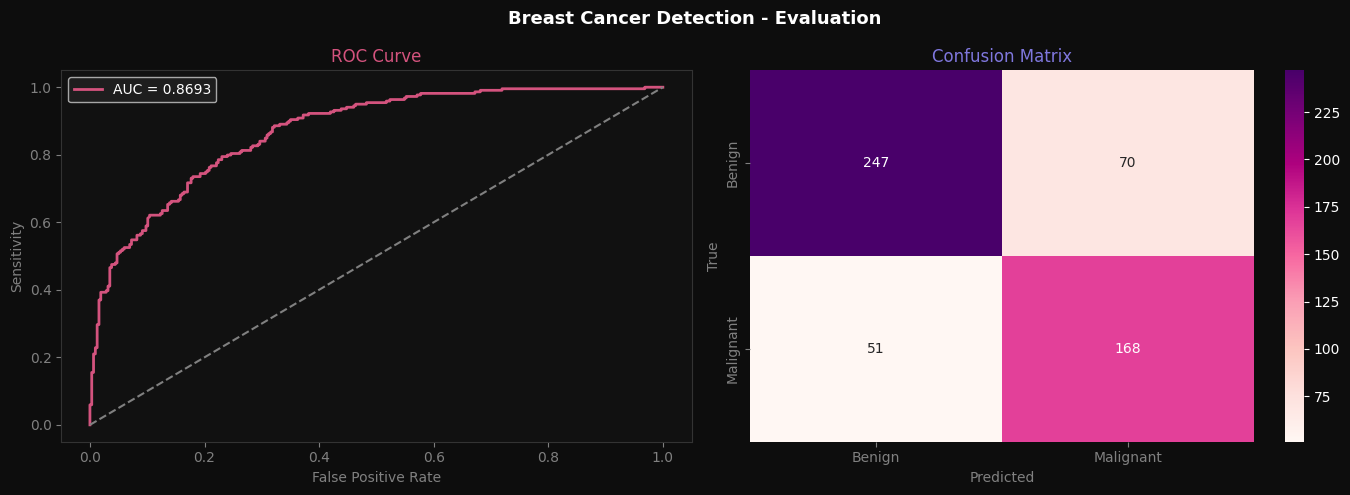

              precision    recall  f1-score   support

      Benign     0.8289    0.7792    0.8033       317
   Malignant     0.7059    0.7671    0.7352       219

    accuracy                         0.7743       536
   macro avg     0.7674    0.7732    0.7692       536
weighted avg     0.7786    0.7743    0.7755       536

AUC: 0.8693  (target >0.85)


In [10]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report
)

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'breast_det')
OUT    = os.path.join(BASE, 'outputs', 'nb07_breast_det')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_path = os.path.join(CKPT, 'breast_det_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]}, AUC={ckpt["best_auc"]:.4f})')

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for imgs, labels in va_dl:
        logits = model(imgs.to(DEVICE))
        probs  = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)
preds_bin  = (all_probs >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = auc(fpr, tpr)

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
fig.suptitle('Breast Cancer Detection - Evaluation',
             color='white', fontsize=13, fontweight='bold')

# ROC curve
axes[0].plot(fpr, tpr, color='#D4537E', linewidth=2,
             label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0,1], [0,1], color='gray', linestyle='--')
axes[0].set_xlabel('False Positive Rate', color='gray')
axes[0].set_ylabel('Sensitivity', color='gray')
axes[0].set_title('ROC Curve', color='#D4537E')
axes[0].legend(fontsize=10, facecolor='#222', labelcolor='white')
axes[0].set_facecolor('#111')
axes[0].spines[:].set_color('#333')
axes[0].tick_params(colors='gray')

# Confusion matrix
cm = confusion_matrix(all_labels, preds_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Benign','Malignant'],
            yticklabels=['Benign','Malignant'], ax=axes[1])
axes[1].set_title('Confusion Matrix', color='#7F77DD')
axes[1].set_ylabel('True', color='gray')
axes[1].set_xlabel('Predicted', color='gray')
axes[1].tick_params(colors='gray')

plt.tight_layout()
plt.savefig(os.path.join(OUT, 'roc_confusion.png'), dpi=120,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print(classification_report(
    all_labels, preds_bin,
    target_names=['Benign','Malignant'], digits=4
))
print(f'AUC: {roc_auc:.4f}  (target >0.85)')

---
## Cell 10 - Training Curves

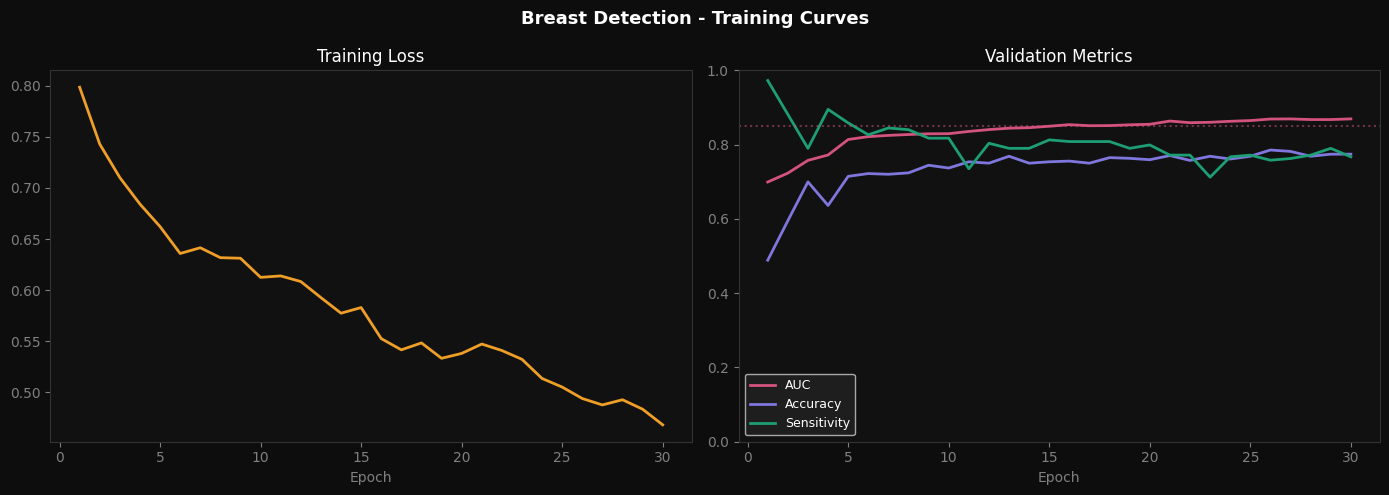

Best epoch   : 30
  AUC        : 0.8693  (target >0.85)
  Accuracy   : 0.7743
  Sensitivity: 0.7671


In [11]:
import os, torch
import matplotlib.pyplot as plt

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'breast_det')
OUT    = os.path.join(BASE, 'outputs', 'nb07_breast_det')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = os.path.join(CKPT, 'breast_det_last.pth')
if not os.path.exists(ckpt_path):
    print('No checkpoint - run training first')
else:
    history = torch.load(ckpt_path, map_location=DEVICE,
                         weights_only=False).get('history', [])

    epochs  = [h['epoch']      for h in history]
    losses  = [h['train_loss'] for h in history]
    aucs    = [h['val_auc']    for h in history]
    accs    = [h['val_acc']    for h in history]
    sens    = [h['sensitivity'] for h in history]

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
    fig.suptitle('Breast Detection - Training Curves',
                 color='white', fontsize=13, fontweight='bold')

    axes[0].plot(epochs, losses, color='#EF9F27', linewidth=2)
    axes[0].set_title('Training Loss', color='white')
    axes[0].set_xlabel('Epoch', color='gray')
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray')

    axes[1].plot(epochs, aucs,  color='#D4537E', linewidth=2, label='AUC')
    axes[1].plot(epochs, accs,  color='#7F77DD', linewidth=2, label='Accuracy')
    axes[1].plot(epochs, sens,  color='#1D9E75', linewidth=2, label='Sensitivity')
    axes[1].axhline(0.85, color='#D4537E', linestyle=':', alpha=0.5)
    axes[1].set_title('Validation Metrics', color='white')
    axes[1].set_xlabel('Epoch', color='gray')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=9, facecolor='#222', labelcolor='white')
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')
    axes[1].tick_params(colors='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'training_curves.png'), dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()

    best = max(history, key=lambda h: h['val_auc'])
    print(f'Best epoch   : {best["epoch"]}')
    print(f'  AUC        : {best["val_auc"]:.4f}  (target >0.85)')
    print(f'  Accuracy   : {best["val_acc"]:.4f}')
    print(f'  Sensitivity: {best["sensitivity"]:.4f}')

---
## Cell 11 - ONNX Export

In [12]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = os.path.join(BASE, 'models', 'production', 'breast_det')
os.makedirs(OUT, exist_ok=True)

onnx_path = os.path.join(OUT, 'breast_det_efficientnet.onnx')

best_path = os.path.join(BASE, 'checkpoints', 'breast_det', 'breast_det_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]})')

model.eval()
model.cpu()
dummy = torch.zeros(1, 3, 512, 512)

try:
    torch.onnx.export(
        model, dummy, onnx_path,
        export_params=True, opset_version=17,
        input_names=['input'], output_names=['logit'],
        dynamic_axes={'input': {0: 'batch_size'}}
    )
    sz = os.path.getsize(onnx_path) / (1024**2)
    print(f'ONNX: {onnx_path}')
    print(f'Size: {sz:.1f} MB')

    import onnx, onnxruntime as ort
    onnx.checker.check_model(onnx.load(onnx_path))
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    out  = sess.run(None, {'input': dummy.numpy()})
    print(f'Inference OK: {out[0].shape}')
    print('ONNX OK')
except Exception as e:
    print(f'ONNX failed: {e}')
finally:
    model.to(DEVICE)

Loaded best model (epoch 29)
ONNX: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\production\breast_det\breast_det_efficientnet.onnx
Size: 70.7 MB
Inference OK: (1, 1)
ONNX OK


---
## Cell 12 - Summary

In [13]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'breast_det')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 65)
print('  NOTEBOOK 07 - BREAST CANCER DETECTION')
print('=' * 65)

for tag in ['best', 'last']:
    p = os.path.join(CKPT, f'breast_det_{tag}.pth')
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
        m    = ckpt.get('metrics', {})
        print(f'  {tag:5} checkpoint: epoch {ckpt["epoch"]:3d}, '
              f'AUC={m.get("val_auc",0):.4f}, '
              f'sens={m.get("sensitivity",0):.4f}')

onnx_p = os.path.join(BASE, 'models', 'production', 'breast_det',
                      'breast_det_efficientnet.onnx')
print(f'  ONNX : {"OK" if os.path.exists(onnx_p) else "not done yet"}')
print()
print('  Model      : EfficientNet-B4 (binary)')
print('  Preprocessing: CLAHE (essential for mammography)')
print('  Loss       : BCEWithLogitsLoss (class-weighted)')
print('  Target     : AUC >0.85, Sensitivity >0.85')
print()
print('  After ONNX verified: delete CBIS-DDSM if needed')
print()
print('  Next: 08_Skin_Classification.ipynb')
print('    - HAM10000 + ISIC 2020')
print('    - 7-class dermoscopy')
print('    - 58:1 class imbalance')
print('=' * 65)

  NOTEBOOK 07 - BREAST CANCER DETECTION
  best  checkpoint: epoch  29, AUC=0.8693, sens=0.7671
  last  checkpoint: epoch  29, AUC=0.8693, sens=0.7671
  ONNX : OK

  Model      : EfficientNet-B4 (binary)
  Preprocessing: CLAHE (essential for mammography)
  Loss       : BCEWithLogitsLoss (class-weighted)
  Target     : AUC >0.85, Sensitivity >0.85

  After ONNX verified: delete CBIS-DDSM if needed

  Next: 08_Skin_Classification.ipynb
    - HAM10000 + ISIC 2020
    - 7-class dermoscopy
    - 58:1 class imbalance
